# GeoClip Zero-Shot Baseline

Evaluate pretrained GeoClip on the MMlandmarks query set **without fine-tuning**.
The model embeds query ground images and gallery GPS coordinates into a shared
512-dim space, then retrieves the nearest GPS by cosine similarity.

**Gallery:** 17,557 train landmark GPS coordinates (closed-world).
**Queries:** 1,000 query landmarks (first ground image per landmark).
**Metric:** Accuracy @ {1, 25, 200, 750, 2500} km (Haversine distance).

## 1. Setup

In [1]:
from pathlib import Path
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import yaml

plt.rcParams.update({"figure.dpi": 120})

# Load config
with open("../../configs/geoclip_baseline.yaml") as f:
    cfg = yaml.safe_load(f)

DATA_ROOT = Path("../../") / cfg["data"]["root"]
assert DATA_ROOT.exists(), f"DATA_ROOT not found: {DATA_ROOT}"

device = cfg["inference"]["device"] if torch.cuda.is_available() else "cpu"
print(f"Device: {device}")
print(f"Data root: {DATA_ROOT.resolve()}")

Device: cpu
Data root: /dtu/blackhole/02/137570/MML


## 2. Load Model

In [2]:
from mmgeo.geolocalizations.geoclip.geoclip_baseline import (
    GeoClipBaseline,
    load_gallery_coords,
    load_query_data,
)
from mmgeo.geolocalizations.geoclip.evaluate import (
    accuracy_at_thresholds,
    median_error,
    haversine,
)

baseline = GeoClipBaseline(device=device)

total_params = sum(p.numel() for p in baseline.model.parameters())
trainable_params = sum(p.numel() for p in baseline.model.parameters() if p.requires_grad)
print(f"Total parameters: {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")

/zhome/57/e/219332/Multimodal-Geo-Spatial-Learning/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Loading weights:   0%|                                                                                                                                                                                      | 0/590 [00:00<?, ?it/s]

Loading weights: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 590/590 [00:00<00:00, 9542.62it/s]


CLIPModel LOAD REPORT from: openai/clip-vit-large-patch14
Key                                  | Status     |  | 
-------------------------------------+------------+--+-
vision_model.embeddings.position_ids | UNEXPECTED |  | 
text_model.embeddings.position_ids   | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Total parameters: 438,050,306
Trainable parameters: 10,432,257


## 3. Build GPS Gallery

In [3]:
gallery_coords = load_gallery_coords(
    DATA_ROOT, include_index=cfg["gallery"]["include_index"]
)
print(f"Gallery size: {len(gallery_coords):,} GPS points")
print(f"Lat range: [{gallery_coords[:, 0].min():.2f}, {gallery_coords[:, 0].max():.2f}]")
print(f"Lon range: [{gallery_coords[:, 1].min():.2f}, {gallery_coords[:, 1].max():.2f}]")

baseline.build_gallery(gallery_coords)
print("Gallery embeddings computed.")

Gallery size: 17,557 GPS points
Lat range: [18.92, 49.00]
Lon range: [-156.00, -66.99]


Gallery embeddings computed.


## 4. Load Query Data

In [4]:
image_paths, true_coords, landmark_ids = load_query_data(DATA_ROOT)
print(f"Query landmarks: {len(image_paths)}")

# Verify all image files exist
missing = [p for p in image_paths if not p.exists()]
if missing:
    print(f"WARNING: {len(missing)} images not found. First missing: {missing[0]}")
else:
    print("All query images found.")

Query landmarks: 1000
All query images found.


## 5. Run Inference

In [5]:
t0 = time.time()
pred_coords = baseline.predict_batch(
    image_paths, batch_size=cfg["inference"]["batch_size"]
)
elapsed = time.time() - t0
print(f"Inference complete: {len(pred_coords)} predictions in {elapsed:.1f}s")

Predicting:   0%|                                                                                                                                                                                         | 0/16 [00:00<?, ?batch/s]

Predicting:   6%|███████████                                                                                                                                                                      | 1/16 [01:16<19:05, 76.38s/batch]

Predicting:  12%|██████████████████████▏                                                                                                                                                          | 2/16 [02:32<17:50, 76.44s/batch]

Predicting:  19%|█████████████████████████████████▏                                                                                                                                               | 3/16 [03:49<16:34, 76.49s/batch]

Predicting:  25%|████████████████████████████████████████████▎                                                                                                                                    | 4/16 [05:05<15:16, 76.35s/batch]

...

Predicting:  88%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████                      | 14/16 [17:49<02:32, 76.30s/batch]

Predicting:  94%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████           | 15/16 [19:05<01:16, 76.31s/batch]

Predicting: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 16/16 [19:53<00:00, 67.73s/batch]

Predicting: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 16/16 [19:53<00:00, 74.58s/batch]

Inference complete: 1000 predictions in 1193.3s


## 6. Evaluate

In [6]:
pred_lat, pred_lon = pred_coords[:, 0], pred_coords[:, 1]
true_lat, true_lon = true_coords[:, 0], true_coords[:, 1]

thresholds = cfg["evaluation"]["thresholds_km"]
results = accuracy_at_thresholds(pred_lat, pred_lon, true_lat, true_lon, thresholds)
med_err = median_error(pred_lat, pred_lon, true_lat, true_lon)
distances = haversine(pred_lat, pred_lon, true_lat, true_lon)

results_df = pd.DataFrame(
    [{"Threshold (km)": t, "Accuracy (%)": f"{acc * 100:.2f}"} for t, acc in results.items()]
)
print(results_df.to_string(index=False))
print(f"\nMedian error: {med_err:.1f} km")
print(f"Mean error: {distances.mean():.1f} km")

 Threshold (km) Accuracy (%)
              1        11.30
             25        23.40
            200        43.10
            750        72.40
           2500        93.90

Median error: 279.8 km
Mean error: 626.5 km


## 7. Visualizations

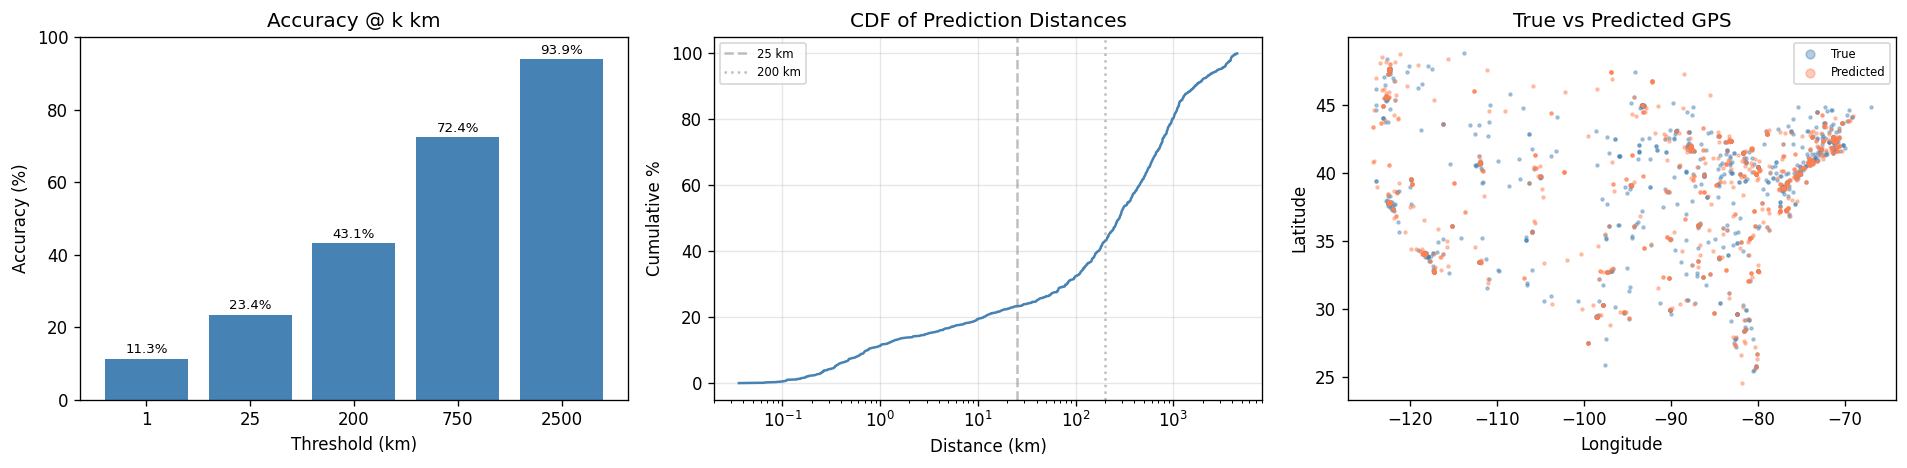

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# (a) Bar chart: accuracy at each threshold
ax = axes[0]
ax.bar([str(t) for t in thresholds], [results[t] * 100 for t in thresholds], color="steelblue")
ax.set_xlabel("Threshold (km)")
ax.set_ylabel("Accuracy (%)")
ax.set_title("Accuracy @ k km")
ax.set_ylim(0, 100)
for i, t in enumerate(thresholds):
    ax.text(i, results[t] * 100 + 1.5, f"{results[t]*100:.1f}%", ha="center", fontsize=8)

# (b) CDF of prediction distances
ax = axes[1]
sorted_dist = np.sort(distances)
cdf = np.arange(1, len(sorted_dist) + 1) / len(sorted_dist)
ax.plot(sorted_dist, cdf * 100, color="steelblue", linewidth=1.5)
ax.set_xscale("log")
ax.set_xlabel("Distance (km)")
ax.set_ylabel("Cumulative %")
ax.set_title("CDF of Prediction Distances")
ax.axvline(25, color="gray", linestyle="--", alpha=0.5, label="25 km")
ax.axvline(200, color="gray", linestyle=":", alpha=0.5, label="200 km")
ax.legend(fontsize=7)
ax.grid(True, alpha=0.3)

# (c) Scatter: true vs predicted GPS
ax = axes[2]
ax.scatter(true_lon, true_lat, s=3, alpha=0.4, label="True", color="steelblue")
ax.scatter(pred_lon, pred_lat, s=3, alpha=0.4, label="Predicted", color="coral")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.set_title("True vs Predicted GPS")
ax.legend(fontsize=7, markerscale=3)

plt.tight_layout()
plt.show()

## 8. Summary for Zero Shot

**Zero-shot GeoClip baseline** on MMlandmarks (1,000 query landmarks, 17,557 train GPS gallery):

| Threshold (km) | Accuracy (%) |
|---------------:|-------------:|
| 1              | 11.30        |
| 25             | 23.40        |
| 200            | 43.10        |
| 750            | 72.40        |
| 2500           | 93.90        |

- **Median error:** 279.8 km
- **Mean error:** 626.5 km
- **Inference time:** 1193.3 s (~20 min) on CPU

The pretrained GeoClip model was trained on 16M globally distributed Flickr images (MP-16).
Since our dataset is US-only, the model predicts globally distributed GPS even for US queries,
explaining the relatively high median error. These results are the **lower bound** before fine-tuning.

**Next steps (Phase 2):** Fine-tune the Location Encoder and linear image head on the
MMlandmarks train split to adapt the model to our US-centric landmark distribution.